In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("power_plant.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT --> temprature
# V --> vaccum
# AP --> pressure
# RH --> humidity
# PE --> peoduce enery

In [5]:
df.shape
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis = 1)
y = df["PE"]

In [7]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [8]:
# Split our data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [12]:
# Scale our data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
import torch
import torch.nn as nn
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)
X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)

In [14]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [15]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)

### Deep Learning

In [19]:
# Define our ANN model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
            
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6,1),
        )

    def forward(self, x):
        return self.model(x)

In [20]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietron = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [18]:
# Train the model
train_loses =[]
val_losses =[]

best_val_loss = float("inf")
epochs = 100


for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #to training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch

        optimizer.zero_grad()
        
        outputs = model(xb) # Forward Propegation.....Predicted outputs for our batch
        loss = crietron(outputs, yb) # compute loss
        loss.backward() # back prop... compute gradients
        optimizer.step() # Parmameter update

        running_loss += loss.item() # loss is a tensor => pyfloat

    epoch_train_loss = running_loss / len(train_loader)
    train_loses.append(epoch_train_loss)

    #Validation
    running_val_loss = 0.0
    model.eval()

    with torch.no_grad(): # no grad compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietron(outputs, yb) # compute loss
            running_val_loss += loss # loss is a tensor => pyfloat

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss

        torch.save(model.state_dict(),"best_model.pt") #.pt or .pth
        
    

epoch 1/100 ==> train loss = 205647.37838541667 & val loss = 202196.78125
epoch 2/100 ==> train loss = 190977.70013020834 & val loss = 174184.21875
epoch 3/100 ==> train loss = 147877.43330078124 & val loss = 118885.125
epoch 4/100 ==> train loss = 89836.64677734375 & val loss = 64907.76171875
epoch 5/100 ==> train loss = 48168.379622395834 & val loss = 36366.72265625
epoch 6/100 ==> train loss = 29388.90426839193 & val loss = 24499.451171875
epoch 7/100 ==> train loss = 21176.830509440104 & val loss = 18646.09375
epoch 8/100 ==> train loss = 16462.0258199056 & val loss = 14542.3125
epoch 9/100 ==> train loss = 12657.263551839193 & val loss = 10810.8564453125
epoch 10/100 ==> train loss = 9111.952256266277 & val loss = 7467.31201171875
epoch 11/100 ==> train loss = 6089.394111124674 & val loss = 4886.4677734375
epoch 12/100 ==> train loss = 3972.6631820678713 & val loss = 3216.606201171875
epoch 13/100 ==> train loss = 2613.091691080729 & val loss = 2180.236083984375
epoch 14/100 ==> t

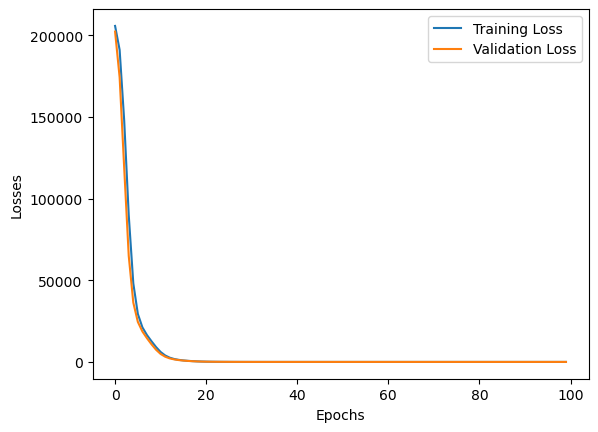

In [21]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({
    "training loss":train_loses,
    "validation loss": val_losses
})

plt.plot(loss_df["training loss"], label = "Training Loss")
plt.plot(loss_df["validation loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [22]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [23]:
# Evaluate our model

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietron( train_preds, X_train_tensor)
    test_mse_loss = crietron( test_preds, X_test_tensor)


print("Training MSE",  train_mse_loss.item())
print("Training MSE",  test_mse_loss.item())


Training MSE 206413.65625
Training MSE 206534.59375


C:\Users\khushi\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\loss.py:630: UserWarning: Using a target size (torch.Size([7654, 4])) that is different to the input size (torch.Size([7654, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\khushi\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\loss.py:630: UserWarning: Using a target size (torch.Size([1914, 4])) that is different to the input size (torch.Size([1914, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [24]:
from sklearn.metrics import r2_score

print("R2_score:", r2_score(y_test, test_preds))

R2_score: 0.9316275477629715


In [25]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns = ["Actual Values"])

pd.concat([predicted_df, actual_df], axis = 1)

,Predicted Values,Actual Values
0,435.244904,433.27
1,437.059937,438.16
2,461.379608,458.42
3,476.261383,480.82
4,435.571838,441.41
...,...,...
1909,451.252869,456.70
1910,431.732849,438.04
1911,467.360657,467.80
1912,431.219482,437.14
